In [ ]:
import pandas as pd

In [5]:
df = pd.read_csv("student_performance_dataset.csv")

df.head()

,study_hours,attendance,previous_score,assignment_score,sleep_hours,final_score
0,4.1,43.1,41.8,44.6,7.8,29.4
1,9.5,71.9,49.5,31.9,4.1,75.8
2,7.5,72.4,42.4,42.7,4.1,50.7
3,6.2,78.2,36.2,70.8,5.6,49.8
4,2.0,83.6,38.4,59.5,6.4,48.6


In [ ]:
print("df shape to  how many rows and columns:")
print(df.shape)
print("df columns to name check for wrong data type to check and colums name:")
print(df.columns)
print("info:")
print(df.info())
print("missing value check:")
print(df.isnull().sum())
print("describe:")
print(df.describe())

df shape to  how many rows and columns:
(300, 6)
df columns to name check for wrong data type to check and colums name:
Index(['study_hours', 'attendance', 'previous_score', 'assignment_score',
       'sleep_hours', 'final_score'],
      dtype='str')
info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   study_hours       300 non-null    float64
 1   attendance        300 non-null    float64
 2   previous_score    300 non-null    float64
 3   assignment_score  300 non-null    float64
 4   sleep_hours       300 non-null    float64
 5   final_score       300 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB
None
missing value check:
study_hours         0
attendance          0
previous_score      0
assignment_score    0
sleep_hours         0
final_score         0
dtype: int64
duplicate value check:
0
describe:
       study_hours  attenda

In [14]:
print("duplicate value check:")
print(df.duplicated().sum())

duplicate value check:
0


In [15]:
import matplotlib.pyplot as plt

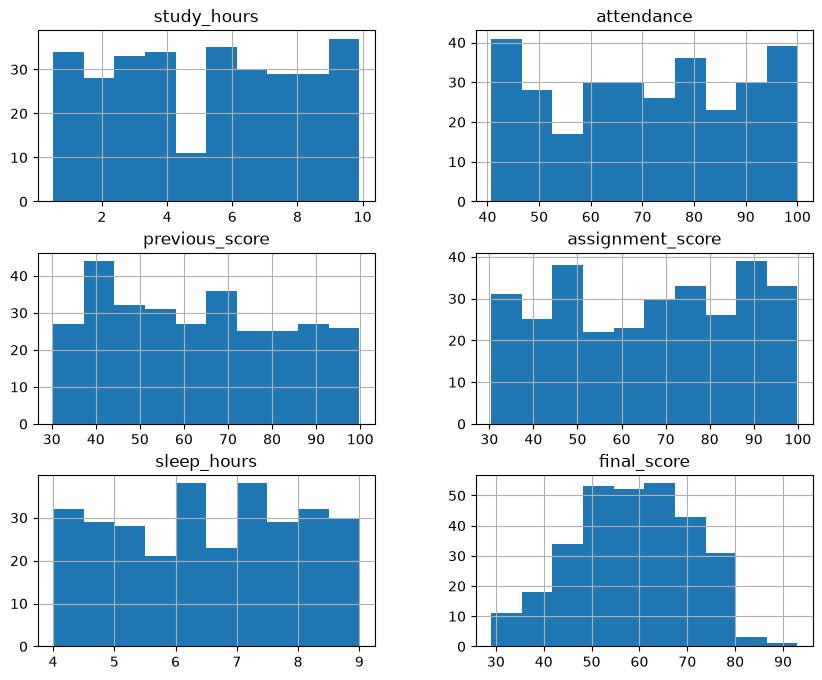

In [16]:
df.hist(figsize=(10,8))
plt.show()

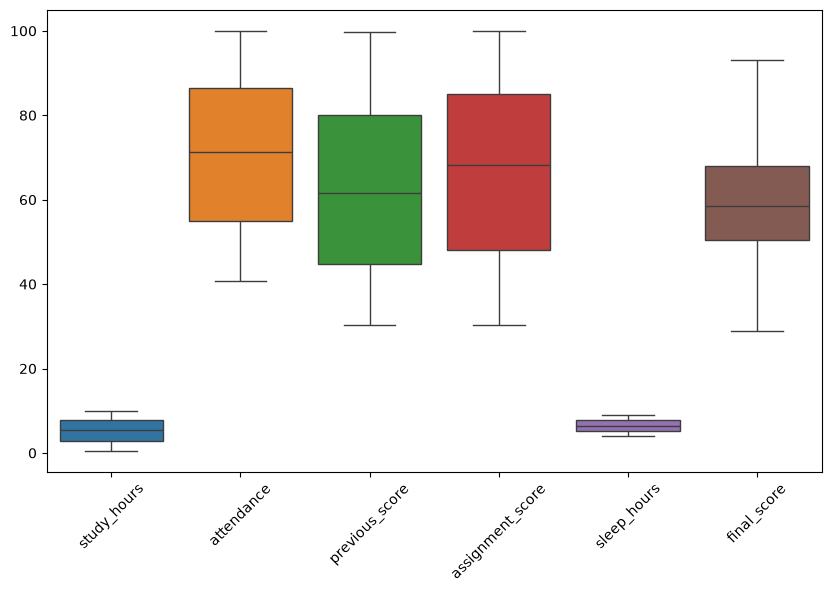

In [17]:
import seaborn as SNS
plt.figure(figsize=(10,6))
SNS.boxplot(df)
plt.xticks(rotation = 45)
plt.show()


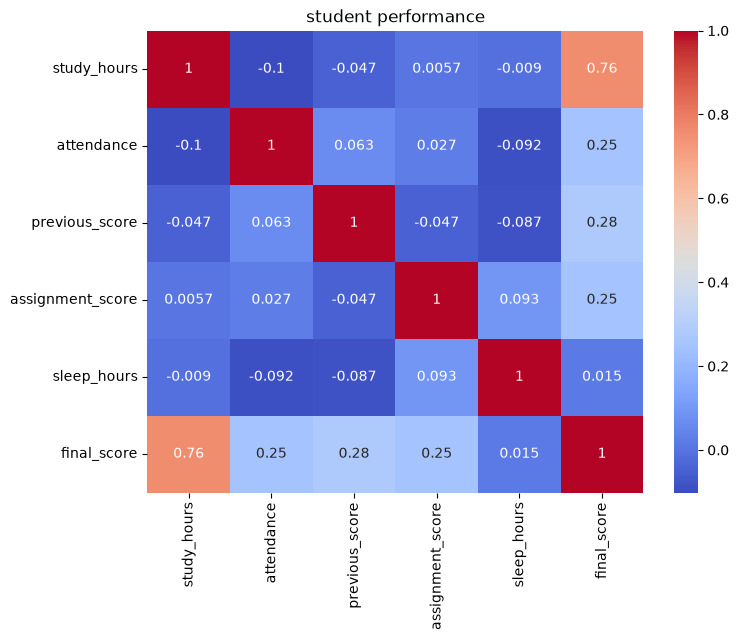

In [19]:
plt.figure(figsize=(8,6))
SNS.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("student performance")
plt.show()

In [22]:
x = df.drop("final_score",axis = 1)
y = df["final_score"]
print("X")
print(x.head())
print("Y")
print(y.head())

X
   study_hours  attendance  previous_score  assignment_score  sleep_hours
0          4.1        43.1            41.8              44.6          7.8
1          9.5        71.9            49.5              31.9          4.1
2          7.5        72.4            42.4              42.7          4.1
3          6.2        78.2            36.2              70.8          5.6
4          2.0        83.6            38.4              59.5          6.4
Y
0    29.4
1    75.8
2    50.7
3    49.8
4    48.6
Name: final_score, dtype: float64


In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

x_train (240, 5)
x_test (60, 5)
y_train (240,)
y_test (60,)


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)
print("x_train_scale:",x_train_scale[:5])

x_train_scale: [[ 0.28677473  1.6050318  -1.14996316 -1.48919234 -0.0569911 ]
 [-0.56468014  0.22641002  0.33672818  0.7276984   0.28667384]
 [-1.4516123   0.03569159 -0.92770034  0.99276143  0.63033879]
 [ 0.57059302  1.29443321  1.50237322 -0.18797386 -0.60685502]
 [-0.88397572  1.26173863 -0.26585103 -1.70124276  0.01174189]]


In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train_scale,y_train)
y_predict = model.predict(x_test_scale)
print("predict value:",y_predict[:10])
print("actual value:",y_test.head(10).values)
print("predict value:",y_predict[:10])

predict value: [82.10147364 63.66968034 51.55012734 65.21052279 52.29446609 65.81868612
 70.04066531 42.11853995 57.02103105 49.38752391]
actual value: [77.  73.7 58.9 69.4 52.5 71.7 67.1 48.7 69.2 47.2]
predict value: [82.10147364 63.66968034 51.55012734 65.21052279 52.29446609 65.81868612
 70.04066531 42.11853995 57.02103105 49.38752391]


In [43]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse = mean_squared_error(y_test,y_predict)
mae = mean_absolute_error(y_test,y_predict)
r2 = r2_score(y_test,y_predict)
print("mse:",mse)
print("mae:",mae)
print("r2score:",r2)

mse: 24.99172768700621
mae: 3.916888826480104
r2score: 0.7993311552815927


In [44]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(x_train_scale,y_train)
y_predict = rf_model.predict(x_test_scale)
print("predict value:",y_predict[:10])
print("actual value:",y_test.head(10).values)
print("predict value:",y_predict[:10])

predict value: [76.78  62.262 52.277 63.276 44.549 69.817 71.433 41.162 56.726 48.276]
actual value: [77.  73.7 58.9 69.4 52.5 71.7 67.1 48.7 69.2 47.2]
predict value: [76.78  62.262 52.277 63.276 44.549 69.817 71.433 41.162 56.726 48.276]


In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_rf = mean_squared_error(y_test, y_predict)
mae_rf = mean_absolute_error(y_test, y_predict)
r2_rf = r2_score(y_test, y_predict)

print("Random Forest MSE:", mse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R2 Score:", r2_rf)

Random Forest MSE: 39.30387611666667
Random Forest MAE: 5.099216666666668
Random Forest R2 Score: 0.6844130381035014


In [47]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(x_train_scale, y_train)

Y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Predictions:")
print(Y_pred_dt[:10])

Decision Tree Predictions:
[93. 93. 93. 93. 93. 93. 93. 93. 93. 93.]


C:\Users\jagad\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [48]:
mse_dt = mean_squared_error(y_test, y_predict)
mae_dt = mean_absolute_error(y_test, y_predict)
r2_dt = r2_score(y_test, y_predict)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree MAE:", mae_dt)
print("Decision Tree R2 Score:", r2_dt)

Decision Tree MSE: 39.30387611666667
Decision Tree MAE: 5.099216666666668
Decision Tree R2 Score: 0.6844130381035014


In [49]:
print("Random Forest:")
print(y_predict[:10])

print("\nDecision Tree:")
print(y_predict[:10])

Random Forest:
[76.78  62.262 52.277 63.276 44.549 69.817 71.433 41.162 56.726 48.276]

Decision Tree:
[76.78  62.262 52.277 63.276 44.549 69.817 71.433 41.162 56.726 48.276]


In [50]:
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

print(coefficients)

            Feature  Coefficient
0       study_hours    10.041266
1        attendance     3.831914
2    previous_score     3.874155
3  assignment_score     2.954438
4       sleep_hours     0.751872


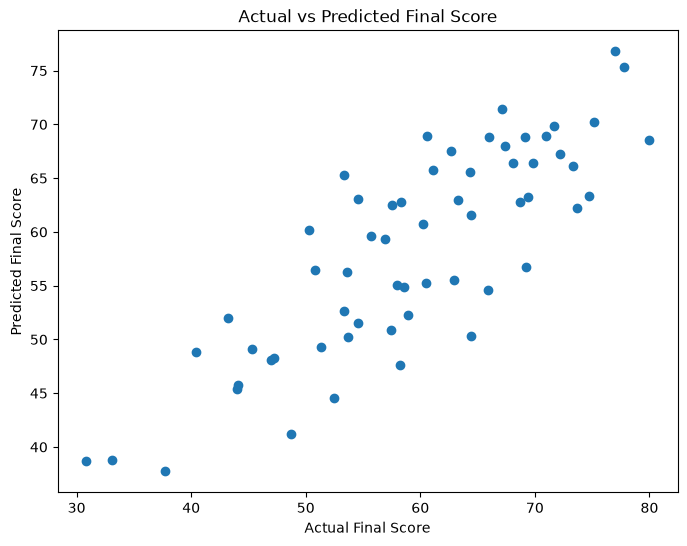

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_predict)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")

plt.show()

In [52]:
import joblib

joblib.dump(model, "student_performance_model.pkl")
joblib.dump(scaler, "student_performance_scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


In [53]:
import joblib
import pandas as pd

model = joblib.load("student_performance_model.pkl")
scaler = joblib.load("student_performance_scaler.pkl")

new_student = pd.DataFrame({
    "study_hours": [6],
    "attendance": [85],
    "previous_score": [70],
    "assignment_score": [75],
    "sleep_hours": [7]
})

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

print("Predicted Final Score:", prediction[0])

Predicted Final Score: 66.9473396059017
